In [ ]:
import numpy as np
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def find_durations(x, dt):
    
    nt, nyear, nz = x.shape

    x = x.astype(int)
    x = np.pad(x, ((1,1), (0,0), (0,0)), constant_values = 0) #for 3D array, only nt dimesnion needs padding

    # Find change points
    changes = np.diff(x, axis = 0)

    yearly_max_duration = np.zeros((nyear, nz), dtype = float)
    for z in range(nz):
        for year in range(nyear):
            start = np.where(changes[:,year,z] ==  1)[0]
            end   = np.where(changes[:,year,z] == -1)[0]
            durations = end - start
            if durations.size > 0:
                yearly_max_duration[year,z] = durations.max()

    avg_max_duration = yearly_max_duration.max(axis = 0) * dt / 24

    return avg_max_duration

def run_trial(elevation, amplitude_annual_cycle):

    dt = 5/60
    time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle, mean_waterlevel = 0., n_years = 100, dt = dt)

    nt = int((24 * 365.25 * 2) / dt)
    nyear = int(waterlevel.size / nt)
    w = waterlevel[:(nt*nyear)].reshape(nyear, nt).T

    dz = 0.02
    inundated = w[:, :, None] >= elevation[None, None, :]
    emergent  = w[:, :, None] <  elevation[None, None, :]

    avg_max_inundation_duration = find_durations(inundated, dt)
    avg_max_emergent_duration = find_durations(emergent, dt)
    avg_max_inundation_duration[avg_max_inundation_duration == avg_max_inundation_duration.max()] = np.nan
    avg_max_emergent_duration[avg_max_emergent_duration == avg_max_emergent_duration.max()] = np.nan

    return avg_max_inundation_duration, avg_max_emergent_duration

#################
## Run simulation (Takes time, don't re-run on accident)
#################

# nz, ntrials = 100, 100
# elevation = np.linspace(-2, 2, nz)[::-1]
# amplitude_annual_cycle = np.linspace(0, 2.0, ntrials)
# avg_max_inundation_duration = np.array([np.nan]*nz*ntrials).reshape(nz,ntrials)
# avg_max_emergent_duration = np.array([np.nan]*nz*ntrials).reshape(nz,ntrials)
# for i in range(ntrials):
#     avg_max_inundation_duration[:,i], avg_max_emergent_duration[:,i] = run_trial(elevation, amplitude_annual_cycle = amplitude_annual_cycle[i])

# elevation_tiled = np.tile(elevation[:,None], reps = (1, ntrials))
# amplitude_annual_cycle_tiled = np.tile(amplitude_annual_cycle[None,:], reps = (nz, 1))
# avg_max_inundation_duration = avg_max_inundation_duration
# avg_max_emergent_duration = avg_max_emergent_duration

# np.save('./bin/supp_note_3/inundation_duration_tests/figure_2c-alt.npy', [elevation_tiled, amplitude_annual_cycle_tiled, avg_max_inundation_duration, avg_max_emergent_duration])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


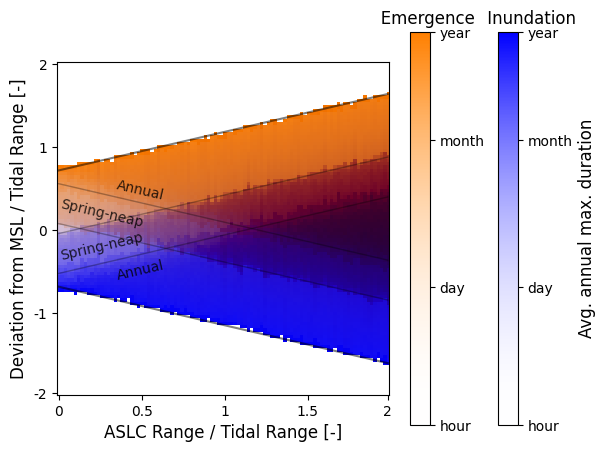

In [604]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

def panel_a(fig, ax, path_bin = './bin/supp_note_3/inundation_duration_tests/figure_2c-alt.npy'):
    
    def blend_arrays(array0, array1):

        array0, array1 = np.log10(array0), np.log10(array1)

        # Normalize arrays between 0 and 1
        a0 = (array0 - np.nanmin(array0)) / (np.nanmax(array0) - np.nanmin(array0))
        a1 = (array1 - np.nanmin(array1)) / (np.nanmax(array1) - np.nanmin(array1))
        a0[np.isnan(a0)] = 0
        a1[np.isnan(a1)] = 0

        # Create RGB image: R from array1, B from array0, G optional
        rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        rgb[..., 0] -= a0   # Red channel = array1
        rgb[..., 1] -= (a1*0.5 + a0)   # Red channel = array1
        rgb[..., 2] -= a1   # Blue channel = array0

        return rgb

    # Define RGBA start and end colors
    start = (1, 1, 1, 0)
    blue = (0, 0, 1, 1)
    orange = (1., 0.5, 0., 1)

    # Create custom colormap
    cmap0 = LinearSegmentedColormap.from_list("transparent_to_blue", [start, blue])
    cmap1 = LinearSegmentedColormap.from_list("transparent_to_orange", [start, orange])

    z, aslc, inund_max, emerg_max = np.load(path_bin)

    nz, ntrials = z.shape

    inund_max[inund_max == 0] = np.nan
    emerg_max[emerg_max == 0] = np.nan
    subset = np.isnan(inund_max) | np.isnan(emerg_max)
    inund_max[subset] = np.nan
    emerg_max[subset] = np.nan

    subtidal, supratidal = 32, 67
    emerge_springneap, emerge_annual = 36, 48
    inund_springneap, inund_annual = 63, 51

    rgb = blend_arrays(inund_max, emerg_max)
    im0 = ax.imshow(rgb)#, cmap = cmap0, vmin = np.log10(1/24))

    # Create dummy mappables for colorbars
    norm = plt.Normalize(vmin=np.log10(1/24), vmax=np.log10(365.25))
    mappable_inund = ScalarMappable(norm=norm, cmap=cmap0)   # Blue
    mappable_emerg = ScalarMappable(norm=norm, cmap=cmap1)   # Orange

    # Add colorbars using dummy mappables
    cbar0 = fig.colorbar(mappable_inund, ax=ax)
    cbar0.ax.set_ylabel('Avg. annual max. duration', fontsize=12)
    cbar0.ax.set_yticks(
        [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)],
        labels=['hour', 'day', 'month', 'year']
    )
    cbar0.ax.set_title('         Inundation', fontsize=12)

    cbar1 = fig.colorbar(mappable_emerg, ax=ax)
    cbar1.ax.set_yticks(
        [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)],
        labels=['hour', 'day', 'month', 'year']
    )
    cbar1.ax.set_title('   Emergence', fontsize=12)

    ax.set_xlabel('ASLC Range / Tidal Range [-]', fontsize = 12)
    ax.set_ylabel('Deviation from MSL / Tidal Range [-]', fontsize = 12)
    ax.set_xticks(ticks = [0, 25, 50, 75, 99], labels = [0, 0.5, 1, 1.5, 2])
    ax.set_yticks(ticks = [0, 25, 50, 75, 99], labels = [2, 1, 0, -1, -2])

    ax.plot([0, ntrials - 1], [subtidal,         subtidal - 23],         c = 'black', alpha = 0.5)
    ax.plot([0, ntrials - 1], [supratidal,       supratidal + 23],       c = 'black', alpha = 0.5)
    ax.plot([0, ntrials - 1], [emerge_springneap,emerge_springneap + 23],c = 'black', lw = 1, alpha = 0.3, zorder = 0)
    ax.plot([0, ntrials - 1], [emerge_annual,    emerge_annual + 23],    c = 'black', lw = 1, alpha = 0.3, zorder = 0)
    ax.plot([0, ntrials - 1], [inund_springneap, inund_springneap - 23], c = 'black', lw = 1, alpha = 0.3, zorder = 0)
    ax.plot([0, ntrials - 1], [inund_annual,     inund_annual - 23],     c = 'black', lw = 1, alpha = 0.3, zorder = 0)

    ax.text( 0, 45, s = 'Spring-neap', rotation = -13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 0, 55, s = 'Spring-neap', rotation =  13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(17, 38, s = 'Annual',      rotation = -13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(17, 62, s = 'Annual',      rotation =  13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)

def figure_multipanel(path_png = None):

    rows, cols = 1, 1
    fig = plt.figure(figsize=((6.4 + 0.3)*cols,(4.8 + 0.3)*rows))
    gs = fig.add_gridspec(rows, cols, hspace=.15, wspace=.15) 

    ax0 = fig.add_subplot(gs[0,0])
    panel_a(fig, ax0)
    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_multipanel('./figures/supp_note_3/inundation_duration_tests/figure_2c-alt.png')